In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, colors

In [3]:
def f(x, y):
    return 2*(np.pi-np.acos(x - y + 1))

n = 2
residual_flux = np.linspace(0, 1, 10*n)
saturation_flux = np.linspace(1, 2, 10*n)
X, Y = np.meshgrid(residual_flux, saturation_flux)
Z = f(X, Y)
print(Z.max(), Z.min())
print(f(X, Y)[-1:])
print(f(X, Y)[:1])

6.283185307179586 0.0
[[0.         0.65176591 0.92590946 1.13924264 1.32169059 1.48481786
  1.63455142 1.77441654 1.90671845 2.03306898 2.15465386 2.2723816
  2.38697259 2.49901548 2.60900462 2.71736603 2.82447609 2.9306756
  3.03628084 3.14159265]]
[[3.14159265 3.24690447 3.3525097  3.45870921 3.56581927 3.67418069
  3.78416983 3.89621272 4.0108037  4.12853144 4.25011632 4.37646686
  4.50876877 4.64863389 4.79836745 4.96149472 5.14394267 5.35727585
  5.63141939 6.28318531]]


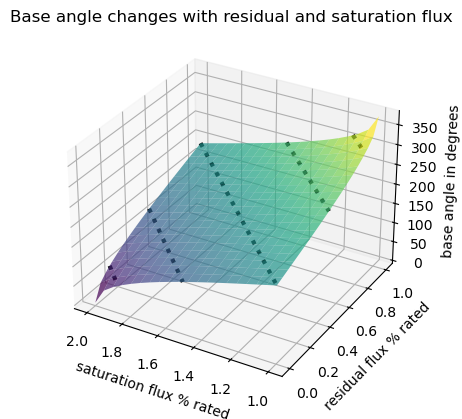

In [4]:
angle_levels = np.linspace(0, 2*np.pi*60, 6+1)

ax = plt.axes(projection='3d')
ax.contour(Y, X, Z*60, alpha=1, linewidths=3, colors='black', linestyles='dotted', levels=angle_levels)
ax.plot_surface(Y, X, Z*60, cmap='viridis', edgecolor='none', alpha=0.7)
ax.set_xlabel("saturation flux % rated")
ax.set_ylabel("residual flux % rated")
ax.set_zlabel("base angle in degrees")
ax.invert_xaxis()
#ax.view_init(-170, 210)
ax.set_title("Base angle changes with residual and saturation flux")
plt.show()

In [14]:
import math
test_series = np.array([0.0, -math.inf, 100.0, math.nan, 50.0, math.inf])
print(test_series.max())
print(test_series[np.isfinite(test_series)].max())

nan
100.0


nan nan


C:\Users\sunjuichih\AppData\Local\Temp\ipykernel_24516\3201886794.py:5: RuntimeWarning: divide by zero encountered in divide
  theta = 0.9*np.arccos((2.03 - x - y)/x)
C:\Users\sunjuichih\AppData\Local\Temp\ipykernel_24516\3201886794.py:5: RuntimeWarning: invalid value encountered in arccos
  theta = 0.9*np.arccos((2.03 - x - y)/x)


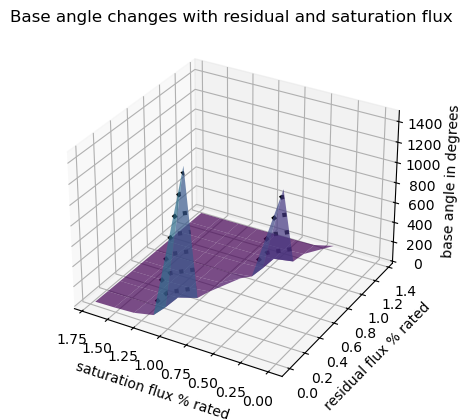

In [21]:
def f(x, y):
    # 2.03 saturation flux
    # x regular flux caused by current
    # y residual flux
    theta = 0.9*np.arccos((2.03 - x - y)/x)
    voltage_peak = 100*np.sqrt(2)
    impetance = 11.1740  # ohm
    inrush_current = voltage_peak/(impetance*(1-np.cos(theta)))

    return inrush_current

n = 1
bm = 1.7
br = bm * 0.8  # Assuming br is 80% of bm
regular_flux = np.linspace(0, bm, 10**n)
residual_flux = np.linspace(0, br, 10**n)
X, Y = np.meshgrid(regular_flux, residual_flux)
Z = f(X, Y)
print(Z.max(), Z.min())
#print(f(X, Y)[-1:])
#print(f(X, Y)[:1])

#angle_levels = np.linspace(0, 2*np.pi*60, 6+1)

ax = plt.axes(projection='3d')
#ax.contour(Y, X, Z, alpha=1, linewidths=3, colors='black', linestyles='dotted', levels=angle_levels)
ax.contour(X, Y, Z, alpha=1, linewidths=3, colors='black', linestyles='dotted')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.7)
ax.set_xlabel("saturation flux % rated")
ax.set_ylabel("residual flux % rated")
ax.set_zlabel("base angle in degrees")
ax.invert_xaxis()
#ax.view_init(-170, 210)
ax.set_title("Base angle changes with residual and saturation flux")
plt.show()

Text(0.5, 1.0, 'Ideal inrush current waveform')

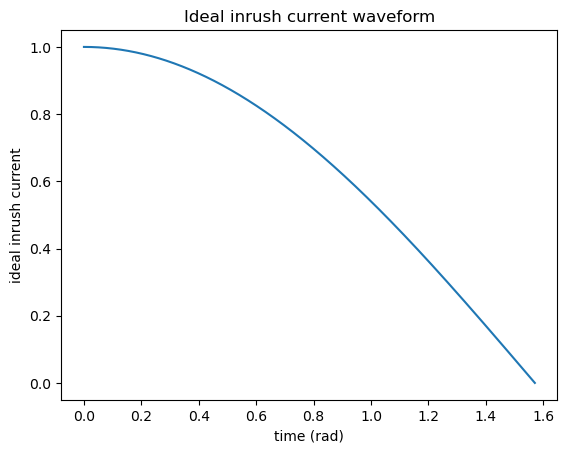

In [6]:
alpha = 2*np.pi/4
def ideal_inrush_current(x):
    return np.cos(x) - np.cos(alpha)

delta_t = 0.00001
#t_grid = np.linspace(-alpha, 2*np.pi+alpha, int(1/delta_t))
t_grid = np.linspace(0, alpha, int(1/delta_t))
I = ideal_inrush_current(t_grid)
I[I < 0] = 0
plt.plot(t_grid, I)
plt.xlabel("time (rad)")
plt.ylabel("ideal inrush current")
plt.title("Ideal inrush current waveform")

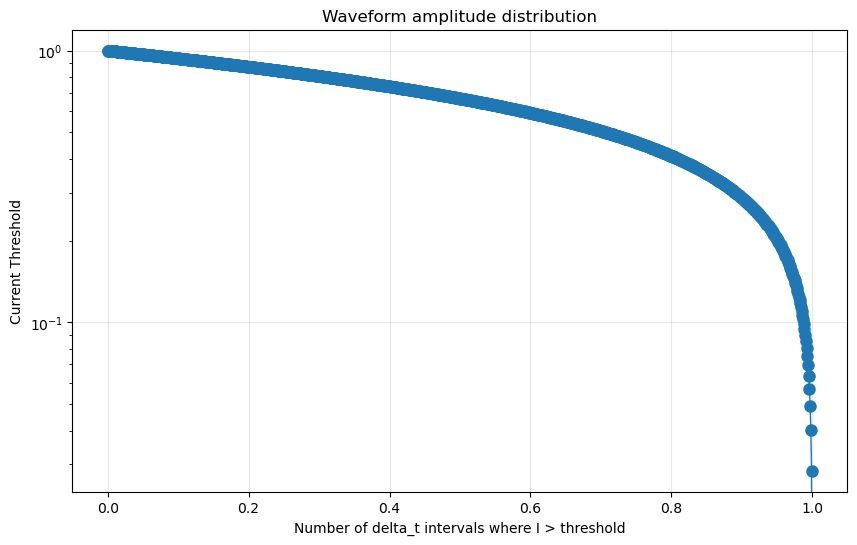

In [7]:
thresholds = np.linspace(0, I.max(), 1000)
counts = [np.sum(I > threshold)/len(I) for threshold in thresholds]

plt.figure(figsize=(10, 6))
plt.plot( thresholds, counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()

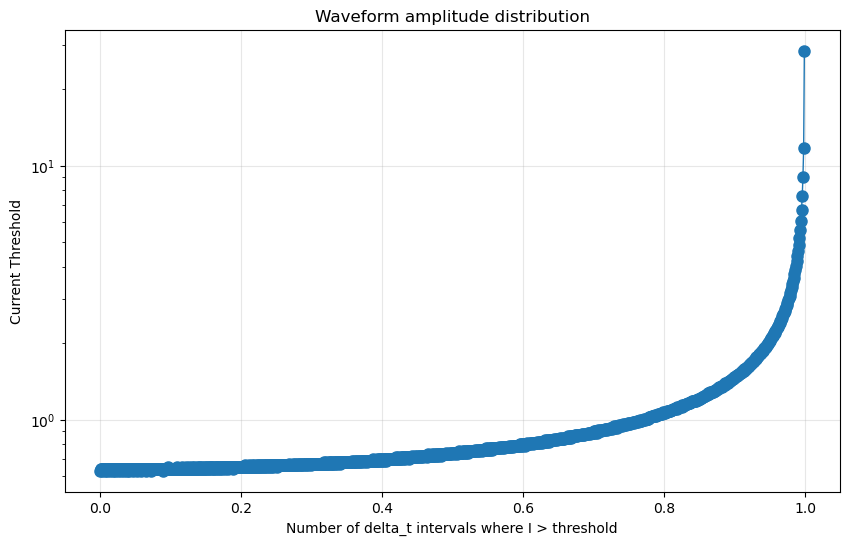

In [8]:
thresholds = np.linspace(0, I.max(), 1000)
derivative_counts = []
for i in range(len(thresholds)-1):
    derivative = (counts[i+1]-counts[i])/(thresholds[i+1]-thresholds[i])
    derivative_counts.append(-derivative)

plt.figure(figsize=(10, 6))
plt.plot( thresholds[:-1], derivative_counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()